In [5]:
import os
import random
import numpy as np
import pandas as pd
import re

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

from tqdm.auto import tqdm
from IPython.display import display

from transformers import BertTokenizer, BertModel

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from collections import defaultdict

from sklearn.manifold import TSNE

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [6]:
# 시드 고정, baseline utils.py에서 가져옴
def seed_everything(seed):
    '''
    [description]
    seed 값을 고정시키는 함수입니다.

    [arguments]
    seed : seed 값
    '''
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

In [7]:
# ㅣㄷ바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
random_state = 42
seed_everything(random_state)

In [9]:
base_path = '/data/ephemeral/home/'
data_path = os.path.join(base_path, 'sch/data/')

books = pd.read_csv(data_path+'books.csv')
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149570 entries, 0 to 149569
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   isbn                 149570 non-null  object 
 1   book_title           149570 non-null  object 
 2   book_author          149569 non-null  object 
 3   year_of_publication  149570 non-null  float64
 4   publisher            149570 non-null  object 
 5   img_url              149570 non-null  object 
 6   language             82343 non-null   object 
 7   category             80719 non-null   object 
 8   summary              82343 non-null   object 
 9   img_path             149570 non-null  object 
dtypes: float64(1), object(9)
memory usage: 11.4+ MB


In [10]:
# 1. 카테고리 데이터 정제 함수
def clean_category(text):
    if pd.isna(text):
        return "Unknown" # 결측치는 Unknown으로 처리 (혹은 제외 가능)
    
    # 정규표현식으로 대괄호[], 따옴표'', "" 제거
    clean_text = re.sub(r"[\[\]'\"']", "", str(text))
    return clean_text.strip()


# 2. 정제 적용
books['category_clean'] = books['category'].apply(clean_category)


In [11]:
# 3. 분포 계산
# Unknown(결측치)을 제외하고 분석하고 싶다면 아래 줄 주석 해제
# valid_categories = books[books['category_clean'] != 'Unknown']['category_clean']
valid_categories = books['category_clean']

cat_counts = valid_categories.value_counts()
total_unique = len(cat_counts)

# 4. 상위 20개 추출
top_20 = cat_counts.head(20)

# 비율 계산
top_20_ratio = (top_20 / len(books) * 100).round(2)

print(f"=== 카테고리 분석 요약 ===")
print(f"총 고유 카테고리 수: {total_unique}개")
print(f"상위 1위 카테고리: {cat_counts.index[0]} ({cat_counts.iloc[0]}개)")
print("\n=== 상위 20개 카테고리 분포 ===")
print(pd.DataFrame({'Count': top_20, 'Ratio (%)': top_20_ratio}))
'''
# 5. 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x=top_20.values, y=top_20.index, palette='viridis')
plt.title(f'Top 20 Categories Distribution (Total Unique: {total_unique})')
plt.xlabel('Count')
plt.ylabel('Category')

# 막대 옆에 수치 표시
for i, v in enumerate(top_20.values):
    plt.text(v + 100, i, f'{v}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 6. 롱테일(Long-tail) 확인: 데이터가 너무 희소하지 않은지?
single_count_cats = (cat_counts == 1).sum()
print(f"\n[참고] 책이 딱 1권만 있는 희소 카테고리 수: {single_count_cats}개")
print(f"      (전체 카테고리의 {single_count_cats/total_unique*100:.1f}%)")
'''

=== 카테고리 분석 요약 ===
총 고유 카테고리 수: 4292개
상위 1위 카테고리: Unknown (68851개)

=== 상위 20개 카테고리 분포 ===
                           Count  Ratio (%)
category_clean                             
Unknown                    68851      46.03
Fiction                    32956      22.03
Juvenile Fiction            5804       3.88
Biography & Autobiography   3320       2.22
History                     1925       1.29
Religion                    1818       1.22
Juvenile Nonfiction         1417       0.95
Social Science              1231       0.82
Humor                       1161       0.78
Body, Mind & Spirit         1109       0.74
Business & Economics        1070       0.72
Cooking                     1025       0.69
Health & Fitness             968       0.65
Family & Relationships       959       0.64
Computers                    730       0.49
Travel                       651       0.44
Self-Help                    640       0.43
Psychology                   635       0.42
Poetry                       

'\n# 5. 시각화\nplt.figure(figsize=(12, 8))\nsns.barplot(x=top_20.values, y=top_20.index, palette=\'viridis\')\nplt.title(f\'Top 20 Categories Distribution (Total Unique: {total_unique})\')\nplt.xlabel(\'Count\')\nplt.ylabel(\'Category\')\n\n# 막대 옆에 수치 표시\nfor i, v in enumerate(top_20.values):\n    plt.text(v + 100, i, f\'{v}\', va=\'center\', fontsize=9)\n\nplt.tight_layout()\nplt.show()\n\n# 6. 롱테일(Long-tail) 확인: 데이터가 너무 희소하지 않은지?\nsingle_count_cats = (cat_counts == 1).sum()\nprint(f"\n[참고] 책이 딱 1권만 있는 희소 카테고리 수: {single_count_cats}개")\nprint(f"      (전체 카테고리의 {single_count_cats/total_unique*100:.1f}%)")\n'

# BERT embedding(768차원) 및 이를 이용하여 K-means clustring 진행
## 클러스터링 된 결과는 t-SNE를 통해 시각화 

In [12]:
unique_categories = books['category_clean'].unique()
unique_categories

array(['Actresses', '1940-1949', 'Medical', ..., 'Deafness',
       'Alternative histories',
       'Authors, Canadian (English) 20th century Biography'], dtype=object)

In [13]:
# bert 임베딩 생성
def create_bert_embeddings(categories, model_name='bert-base-uncased', batch_size=64):
    categories = list(categories)
    """Category 텍스트를 BERT 임베딩으로 변환"""
    tokenizer = BertTokenizer.from_pretrained(model_name)
    model = BertModel.from_pretrained(model_name).to(device)
    model.eval()
    
    category_embeddings = {}
    
    with torch.no_grad():
        for i in tqdm(range(0, len(categories), batch_size), desc="Encoding"):
            batch = categories[i:i+batch_size]
            
            inputs = tokenizer(
                batch,  # 리스트를 한번에 처리
                return_tensors='pt', 
                padding=True, 
                truncation=True,
                max_length=128
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            outputs = model(**inputs)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            
            for j, category in enumerate(batch):
                category_embeddings[category] = cls_embeddings[j]
    
    return category_embeddings

# 클러스터링, 중심벡터 추출해서 저장
def cluster_categories(embedding_matrix, n_clusters):
    """K-Means로 클러스터링하고 매핑 정보 반환"""
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    cluster_labels = kmeans.fit_predict(embedding_matrix)

    # 만들어진 cluster를 바탕으로 mapping dictionary 생성
    category_to_cluster = {
        cat: cluster_labels[idx] 
        for idx, cat in enumerate(unique_categories)
    }
    
    return kmeans, cluster_labels, category_to_cluster

In [14]:
# Category Unique value들 embedding생성
category_embeddings = create_bert_embeddings(unique_categories)
embedding_matrix = np.array([category_embeddings[cat] for cat in unique_categories])

Encoding:   0%|          | 0/68 [00:00<?, ?it/s]

# 클러스터링 크기 리스트 선언 후 클러스터링 진행

In [15]:
#cluster_list = [15,20,30,50,100,200]
cluster_list = [15]
kmeans_list = []
labels_list = []
cat_to_cluster_list = []

In [16]:
for N_CLUSTERS in cluster_list:
    kmeans, cluster_labels, category_to_cluster = cluster_categories(embedding_matrix, N_CLUSTERS)
    kmeans_list.append(kmeans)
    labels_list.append(cluster_labels)
    cat_to_cluster_list.append(category_to_cluster)

In [17]:
# t-SNE
print("t-SNE 차원 축소 시작...")
tsne = TSNE(
    n_components=2,
    random_state=random_state,
    perplexity=30,
    max_iter=1000,
    verbose=1
)
embeddings_2d = tsne.fit_transform(embedding_matrix)

t-SNE 차원 축소 시작...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 4292 samples in 0.002s...
[t-SNE] Computed neighbors for 4292 samples in 0.576s...
[t-SNE] Computed conditional probabilities for sample 1000 / 4292
[t-SNE] Computed conditional probabilities for sample 2000 / 4292
[t-SNE] Computed conditional probabilities for sample 3000 / 4292
[t-SNE] Computed conditional probabilities for sample 4000 / 4292
[t-SNE] Computed conditional probabilities for sample 4292 / 4292
[t-SNE] Mean sigma: 1.804375
[t-SNE] KL divergence after 250 iterations with early exaggeration: 82.007408
[t-SNE] KL divergence after 1000 iterations: 1.622264


In [18]:
# 클러스터링 끝난 후 t-SNE 시각화
def tSNE_vis(embeddings_2d):
    plt.figure(figsize=(12, 8))

    scatter = plt.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        c=cluster_labels,
        cmap='tab20',
        s=100,
        alpha=0.6,
        edgecolors='black',
        linewidth=0.5
    )

    # 클러스터 중심에 클러스터 번호 표시
    for cluster_id in range(N_CLUSTERS):
        cluster_points = embeddings_2d[cluster_labels == cluster_id]
        center_x = cluster_points[:, 0].mean()
        center_y = cluster_points[:, 1].mean()
        
        plt.annotate(
            f'C{cluster_id}',
            xy=(center_x, center_y),
            fontsize=12,
            fontweight='bold',
            ha='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7)
        )

    plt.colorbar(scatter, label='Cluster ID')
    plt.title(f't-SNE Visualization of {N_CLUSTERS} Category Clusters', fontsize=16)
    plt.xlabel('t-SNE Component 1', fontsize=12)
    plt.ylabel('t-SNE Component 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('tsne_clusters.png', dpi=300, bbox_inches='tight')
    plt.show()

15개로 클러스터링 된 결과 t-SNE로 시각화


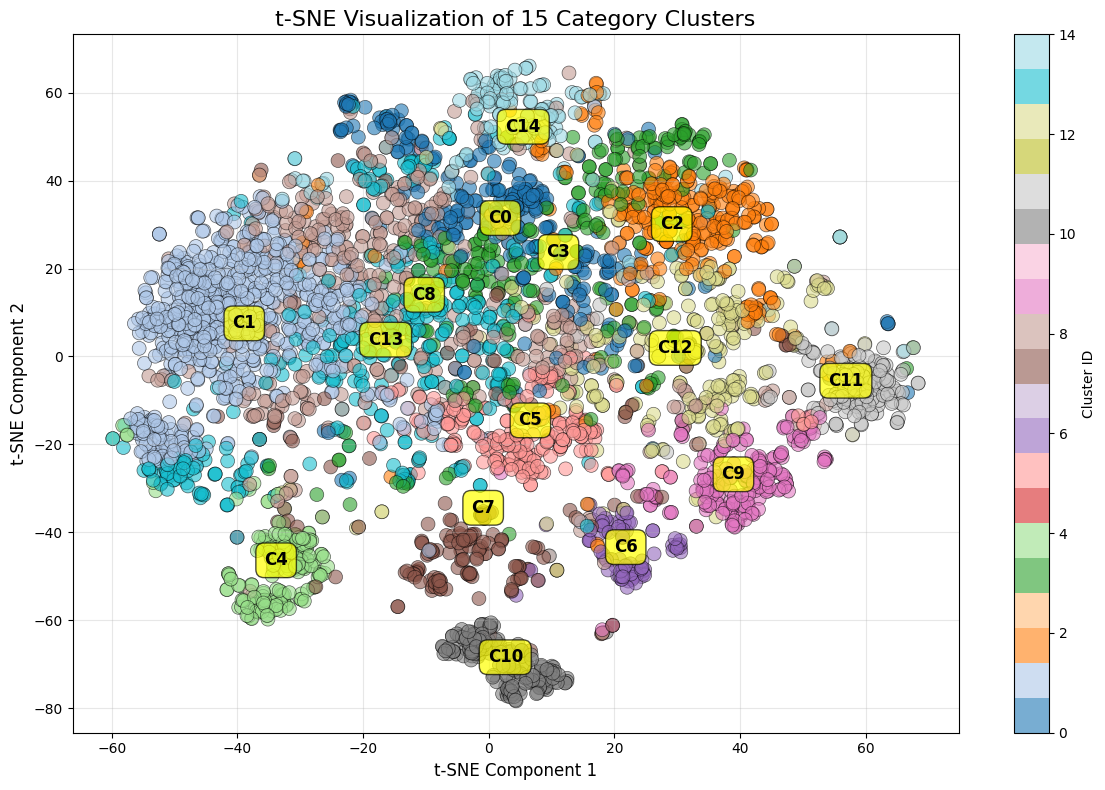

In [19]:
#for i in range(1):
for i in range(len(cluster_list)):

    N_CLUSTERS = cluster_list[i]
    cluster_labels = labels_list[i]
    print(f"{N_CLUSTERS}개로 클러스터링 된 결과 t-SNE로 시각화")
    tSNE_vis(embeddings_2d)

# 클러스터링 된 결과 확인해보기

In [20]:
check_cluster_size = 15
num_to_use = cluster_list.index(check_cluster_size)

In [21]:
cat_to_cluster_list[num_to_use]

{'Actresses': 1,
 '1940-1949': 12,
 'Medical': 1,
 'Fiction': 5,
 'History': 13,
 'Unknown': 13,
 'Nature': 1,
 'Humor': 1,
 'Cooking': 8,
 'Reference': 1,
 'Juvenile Fiction': 5,
 'Canadian fiction': 5,
 'Health & Fitness': 13,
 'FICTION': 5,
 'Control (Psychology)': 2,
 'Cholistan Desert (Pakistan)': 4,
 'Science': 1,
 'Conduct of life': 12,
 'Horses': 1,
 'Political Science': 2,
 'Brothers': 1,
 'Baggins, Frodo (Fictitious character)': 10,
 'Biography & Autobiography': 13,
 'Business & Economics': 2,
 'Americans': 13,
 'Infanticide': 14,
 'Cabala': 1,
 'Literary Criticism': 2,
 'Self-Help': 8,
 'American fiction': 1,
 'Humorous stories': 5,
 'Diary fiction': 5,
 'Religion': 2,
 'Oglala Indians': 0,
 'England': 1,
 'Social Science': 2,
 'Michigan': 1,
 'Foster mothers': 8,
 'Adolescence': 8,
 'Dune (Imaginary place)': 7,
 'Animals': 13,
 'Great Britain': 1,
 'London (England)': 4,
 'Music': 1,
 'Mars (Planet)': 7,
 'Fairy tales': 8,
 'Childrens stories': 5,
 'Jews': 1,
 'Fantasy fict

In [22]:
# 각 클러스터에 배정된 키 예시 10개 출력
for i in range(cluster_list[num_to_use]):
    cat_in_cluster = [key for key, value in cat_to_cluster_list[num_to_use].items() if value == i]

    #if len(cat_in_cluster)>270:
    #    continue
    print(f"{i}에 속하는 키 ({len(cat_in_cluster)}개):")
    print('어떤 category가 배정되었는지 출력')
    print(cat_in_cluster[:10])

0에 속하는 키 (290개):
어떤 category가 배정되었는지 출력
['Oglala Indians', 'Fantasy comic books, strips, etc', 'Arthurian romances', 'Ballet dancers', 'Alchemists', 'Geishas', 'Cherokee Indians', 'Extraterrestrial beings', 'Dutch Americans', 'Track and field athletes']
1에 속하는 키 (780개):
어떤 category가 배정되었는지 출력
['Actresses', 'Medical', 'Nature', 'Humor', 'Reference', 'Science', 'Horses', 'Brothers', 'Cabala', 'American fiction']
2에 속하는 키 (330개):
어떤 category가 배정되었는지 출력
['Control (Psychology)', 'Political Science', 'Business & Economics', 'Literary Criticism', 'Religion', 'Social Science', 'Psychology', 'Education', 'Philosophy', 'Astronomy']
3에 속하는 키 (265개):
어떤 category가 배정되었는지 출력
['Aerospace engineers', 'Animal welfare', 'Community colleges', 'Performing Arts', 'Crafts & Hobbies', 'Monastic and religious life', 'Environmental protection', 'Historiography', 'Appetizers', 'Petroleum industry and trade']
4에 속하는 키 (195개):
어떤 category가 배정되었는지 출력
['Cholistan Desert (Pakistan)', 'London (England)', 'Glasgow (Sc

In [23]:
# 각 클러스터에 배정된 키 개수 출력
for target_value in range(cluster_list[num_to_use]):
    cat_in_cluster = [key for key, value in cat_to_cluster_list[num_to_use].items() if value == target_value]
    print(f"{target_value}에 속하는 키 ({len(cat_in_cluster)}개):")


0에 속하는 키 (290개):
1에 속하는 키 (780개):
2에 속하는 키 (330개):
3에 속하는 키 (265개):
4에 속하는 키 (195개):
5에 속하는 키 (261개):
6에 속하는 키 (95개):
7에 속하는 키 (201개):
8에 속하는 키 (453개):
9에 속하는 키 (238개):
10에 속하는 키 (171개):
11에 속하는 키 (175개):
12에 속하는 키 (260개):
13에 속하는 키 (417개):
14에 속하는 키 (161개):


## 클러스터링 된 결과를 바탕으로 category 예측 모델을 위한 새로운 dataframe 생성
### df_for catpred['category_cluster']에 클러스터링 된 결과로 카테고리 라벨링
### 예측을 위해 필요없다고 판단되는 열들은 exclude_cols 선언을 통해 제외

In [24]:
# 제외할 컬럼
#exclude_cols = ['img_url', 'book_title', 'language', 'category', 'summary', 'img_path']
exclude_cols = ['img_url', 'language', 'category', 'img_path']

# category가 null이 아닌 행만 선택 + 컬럼 제외 + 깊은 복사
df_for_catpred = books[books['category'].notna()].drop(columns=exclude_cols).copy()

# category_cluster 컬럼 추가
df_for_catpred['category_cluster'] = books.loc[books['category'].notna(), 'category_clean'].map(cat_to_cluster_list[num_to_use])
df_for_catpred = df_for_catpred.drop(columns='category_clean')

df_for_catpred.head()

,isbn,book_title,book_author,year_of_publication,publisher,summary,category_cluster
0,0002005018,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada,"In a small town in Canada, Clara Callan reluct...",1
1,0060973129,Decision in Normandy,Carlo D'Este,1991.0,HarperPerennial,"Here, for the first time in paperback, is an o...",12
2,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999.0,Farrar Straus Giroux,"Describes the great flu epidemic of 1918, an o...",1
3,0399135782,The Kitchen God's Wife,Amy Tan,1991.0,Putnam Pub Group,A Chinese immigrant who is convinced she is dy...,5
4,0425176428,What If?: The World's Foremost Military Histor...,Robert Cowley,2000.0,Berkley Publishing Group,"Essays by respected military historians, inclu...",13


In [25]:
# 각 라벨(클러스터)에 해당하는 데이터 샘플 개수 출력
for i in range(cluster_list[num_to_use]):
    sample_num = df_for_catpred['category_cluster'].value_counts().get(i, 0)
    print(f"클러스터 {i}: {sample_num}개")

클러스터 0: 674개
클러스터 1: 9828개
클러스터 2: 8305개
클러스터 3: 1388개
클러스터 4: 380개
클러스터 5: 42888개
클러스터 6: 108개
클러스터 7: 322개
클러스터 8: 3935개
클러스터 9: 704개
클러스터 10: 274개
클러스터 11: 322개
클러스터 12: 2860개
클러스터 13: 8398개
클러스터 14: 333개


## 카테고리 예측하는 기본 CatBoost 모델 학습 및 검증

In [26]:
# input, output 분할
y = df_for_catpred['category_cluster']
X = df_for_catpred.drop(columns=['category_cluster'])

print(f"Features: {X.shape}")
print(f"Target classes: {y.nunique()}")

# 데이터셋 분할
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=random_state,
    stratify=y  # 클래스 비율 유지
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}")

# catboost학습
cat_features = ['isbn', 'book_author', 'publisher']

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=random_state,
    cat_features=cat_features,
    text_features=['book_title', 'summary'],
    verbose=100,
    early_stopping_rounds=50,
    task_type='GPU', 
    devices='0'
)

model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True,
    plot=False
)

# validation accurcay, feature importance 확인
y_val_pred = model.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)

print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

Features: (80719, 6)
Target classes: 15
Train: (64575, 6), Validation: (16144, 6)
0:	learn: 0.6323345	test: 0.6484762	best: 0.6484762 (0)	total: 43.7ms	remaining: 43.6s
100:	learn: 0.6829268	test: 0.6962339	best: 0.6963578 (98)	total: 2.33s	remaining: 20.7s
200:	learn: 0.6885947	test: 0.7001982	best: 0.7002602 (192)	total: 4.46s	remaining: 17.7s
300:	learn: 0.6927913	test: 0.7010654	best: 0.7019326 (268)	total: 6.63s	remaining: 15.4s
bestTest = 0.7019326065
bestIteration = 268
Shrink model to first 269 iterations.
Validation Accuracy: 0.7019 (70.19%)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.01      0.01       135
           1       0.52      0.46      0.49      1966
           2       0.53      0.58      0.56      1661
           3       0.68      0.19      0.30       278
           4       0.00      0.00      0.00        76
           5       0.79      0.95      0.86      8578
           6       0.00      0.00      0

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 클러스터를 만든 경우에 상대적으로 샘플이 적은 클러스터는 아예 예측조차 시도하지 않음
### 이를 해결하기 위해 minor cluster를 모두 묶어 하나의 기타 클러스터로 재라벨링 하는 과정

In [27]:
from collections import Counter

# 1) 각 클러스터별 샘플 수 계산
cluster_counts = df_for_catpred['category_cluster'].value_counts().to_dict()
# 예: {5: 8578, 2: 1661, 1: 1966, 8: 787, 3: 278, 0: 135, 4: 76, ...}

# 2) 샘플 수 기준 내림차순 정렬
sorted_clusters = sorted(cluster_counts.items(), key=lambda x: x[1], reverse=True)
# 예: [(5, 8578), (1, 1966), (2, 1661), (8, 787), (3, 278), (0, 135), (4, 76), ...]

# 3) 샘플수가 threshold 미만인 클러스터를 모아서 하나의 "기타" 클러스터로 묶기
threshold = 705
major_clusters = [c for c, cnt in sorted_clusters if cnt >= threshold]
minor_clusters = [c for c, cnt in sorted_clusters if cnt < threshold]

print("Major clusters :", major_clusters)
print("Minor clusters :", minor_clusters)

Major clusters : [5, 1, 13, 2, 8, 12, 3]
Minor clusters : [9, 0, 4, 14, 11, 7, 10, 6]


In [28]:
# 4) 새 클러스터 인덱스 매핑 생성
#    - major 클러스터: 샘플 수 기준 내림차순으로 0,1,2,... 부여
#    - minor 클러스터: 모두 마지막 인덱스로 묶기
new_cluster_map = {}

# major cluster를 0부터 번호 부여
for new_idx, c in enumerate(major_clusters):
    new_cluster_map[c] = new_idx

# minor cluster는 모두 마지막 인덱스로
other_idx = len(major_clusters)  # 마지막 인덱스
for c in minor_clusters:
    new_cluster_map[c] = other_idx

# 5) df_for_catpred에 적용
df_for_catpred['cluster_reordered'] = df_for_catpred['category_cluster'].map(new_cluster_map)

In [29]:
df_for_catpred_new = df_for_catpred.drop(columns=['isbn', 'book_author', 'category_cluster']).copy()
print(df_for_catpred_new.head())

                                          book_title  year_of_publication  \
0                                       Clara Callan               2001.0   
1                               Decision in Normandy               1991.0   
2  Flu: The Story of the Great Influenza Pandemic...               1999.0   
3                             The Kitchen God's Wife               1991.0   
4  What If?: The World's Foremost Military Histor...               2000.0   

                  publisher  \
0     HarperFlamingo Canada   
1           HarperPerennial   
2      Farrar Straus Giroux   
3          Putnam Pub Group   
4  Berkley Publishing Group   

                                             summary  cluster_reordered  
0  In a small town in Canada, Clara Callan reluct...                  1  
1  Here, for the first time in paperback, is an o...                  5  
2  Describes the great flu epidemic of 1918, an o...                  1  
3  A Chinese immigrant who is convinced she is dy...  

In [30]:
# input, output 분할
y = df_for_catpred_new['cluster_reordered']
X = df_for_catpred_new.drop(columns=['cluster_reordered'])

print(f"Features: {X.shape}")
print(f"Target classes: {y.nunique()}")

# 데이터셋 분리
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=random_state,
    stratify=y  # 클래스 비율 유지
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}")

# catboost학습
cat_features = ['publisher']

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=random_state,
    cat_features=cat_features,
    text_features=['book_title', 'summary'],
    verbose=100,
    early_stopping_rounds=50,
    task_type='GPU', 
    devices='0'
)

model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True,
    plot=False
)

# validation accurcay, feature importance 확인
y_val_pred = model.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)

print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

Features: (80719, 4)
Target classes: 8
Train: (64575, 4), Validation: (16144, 4)
0:	learn: 0.6301045	test: 0.6458746	best: 0.6458746 (0)	total: 20.7ms	remaining: 20.6s
100:	learn: 0.6789160	test: 0.6915263	best: 0.6915263 (98)	total: 1.62s	remaining: 14.4s
200:	learn: 0.6851568	test: 0.6936943	best: 0.6939420 (160)	total: 3.14s	remaining: 12.5s
300:	learn: 0.6895703	test: 0.6967294	best: 0.6967914 (287)	total: 4.62s	remaining: 10.7s
400:	learn: 0.6922184	test: 0.6980922	best: 0.6984638 (389)	total: 6s	remaining: 8.96s
500:	learn: 0.6952691	test: 0.6994549	best: 0.6994549 (494)	total: 7.25s	remaining: 7.22s
600:	learn: 0.6979481	test: 0.7008796	best: 0.7008796 (600)	total: 8.51s	remaining: 5.65s
700:	learn: 0.7005033	test: 0.7014990	best: 0.7016848 (680)	total: 9.73s	remaining: 4.15s
800:	learn: 0.7028262	test: 0.7024901	best: 0.7026140 (769)	total: 11s	remaining: 2.73s
bestTest = 0.7029856293
bestIteration = 824
Shrink model to first 825 iterations.
Validation Accuracy: 0.7030 (70.30%)

## Category column 결측치 모두 채워넣기
### 결측값이 아닌 경우는 이전에 선언된 category - cluster_index mapping 이용해서 채워넣기

In [31]:
#새로운 dataframe 선언
books_categoryfilled = books.copy()
books_categoryfilled['category_cluster'] = np.nan

#결측값 아닌 기존 category에는 기존 매핑 적용
mask_has_clean = books_categoryfilled['category_clean'].notna()

# 기존 15 클러스터 매핑 후, 기타 클러스터 적용된 새 매핑적용 위해 두번 매핑
books_categoryfilled['category_cluster'] = books.loc[books['category'].notna(), 'category_clean'].map(cat_to_cluster_list[num_to_use])
books_categoryfilled['category_cluster'] = df_for_catpred['category_cluster'].map(new_cluster_map)

books_categoryfilled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149570 entries, 0 to 149569
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   isbn                 149570 non-null  object 
 1   book_title           149570 non-null  object 
 2   book_author          149569 non-null  object 
 3   year_of_publication  149570 non-null  float64
 4   publisher            149570 non-null  object 
 5   img_url              149570 non-null  object 
 6   language             82343 non-null   object 
 7   category             80719 non-null   object 
 8   summary              82343 non-null   object 
 9   img_path             149570 non-null  object 
 10  category_clean       149570 non-null  object 
 11  category_cluster     80719 non-null   float64
dtypes: float64(2), object(10)
memory usage: 13.7+ MB


In [32]:
from catboost import Pool

# 결측값인 곳 모델 통해 채워넣기
mask_need_predict = books_categoryfilled['category_cluster'].isna()

# 예측에 사용할 feature
feature_cols = ['summary', 'book_title', 'year_of_publication', 'publisher']

mask_need_predict = books_categoryfilled['category_cluster'].isna()
X_missing = books_categoryfilled.loc[mask_need_predict, feature_cols].copy()

# 1) dtype 정리
# text_features: 문자열로 고정
for col in ['summary', 'book_title']:
    X_missing[col] = X_missing[col].fillna('').astype(str)

# cat_features: 문자열 카테고리로 고정
X_missing['publisher'] = X_missing['publisher'].fillna('').astype(str)

# numeric: 숫자로 강제
X_missing['year_of_publication'] = pd.to_numeric(
    X_missing['year_of_publication'], errors='coerce'
)

# 2) CatBoost 전용 Pool 생성 (학습 시와 동일하게 설정)
cat_features = ['publisher']
text_features = ['book_title', 'summary']

pool_missing = Pool(
    data=X_missing,
    cat_features=cat_features,
    text_features=text_features
)

# 3) 예측
pred_missing = model.predict(pool_missing)

# 4) 결과 채우기
books_categoryfilled.loc[mask_need_predict, 'category_cluster'] = pred_missing

In [33]:
books_categoryfilled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149570 entries, 0 to 149569
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   isbn                 149570 non-null  object 
 1   book_title           149570 non-null  object 
 2   book_author          149569 non-null  object 
 3   year_of_publication  149570 non-null  float64
 4   publisher            149570 non-null  object 
 5   img_url              149570 non-null  object 
 6   language             82343 non-null   object 
 7   category             80719 non-null   object 
 8   summary              82343 non-null   object 
 9   img_path             149570 non-null  object 
 10  category_clean       149570 non-null  object 
 11  category_cluster     149570 non-null  float64
dtypes: float64(2), object(10)
memory usage: 13.7+ MB


In [34]:
print(books_categoryfilled['category_cluster'].value_counts(normalize=True).sort_index().round(4) * 100)

category_cluster
0.0    61.29
1.0    12.04
2.0     7.56
3.0     8.53
4.0     3.75
5.0     2.26
6.0     1.07
7.0     3.50
Name: proportion, dtype: float64


In [35]:
books_final = (books_categoryfilled
               .drop(columns=['category', 'category_clean'])
               .rename(columns={'category_cluster': 'category'})
               .assign(category=lambda df: df['category'].astype(object))
              )
books_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149570 entries, 0 to 149569
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   isbn                 149570 non-null  object 
 1   book_title           149570 non-null  object 
 2   book_author          149569 non-null  object 
 3   year_of_publication  149570 non-null  float64
 4   publisher            149570 non-null  object 
 5   img_url              149570 non-null  object 
 6   language             82343 non-null   object 
 7   summary              82343 non-null   object 
 8   img_path             149570 non-null  object 
 9   category             149570 non-null  object 
dtypes: float64(1), object(9)
memory usage: 11.4+ MB


In [36]:
books_final.to_csv('books_catfilled.csv', index=False, encoding='utf-8')